In [1]:
import pandas as pd
import scipy.stats as stats
import pickle as pkl
from statsmodels.stats.multitest import fdrcorrection
from matplotlib import pyplot as plt
import seaborn as sns
import os
import pickle as pkl
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from brainwidemap import bwm_loading
from one.api import ONE

In [2]:
from communication_subspace.ibl_communication.group_level_rrr import load_cohort_data

In [3]:
one = ONE(
    base_url="https://openalyx.internationalbrainlab.org",
    password="international",
    silent=True,
    username="intbrainlab",
)
sessions = one.search(datasets="widefieldU.images.npy")

In [52]:
trials_path = (
    "/Users/dkundu/Documents/phd/communication_python/data/processed/wifi_trials_df_all.pkl"
)

with open(trials_path, "rb") as f:
    all_trials = pkl.load(f)

In [53]:
session_id = "12046ccd-b737-4c01-bc70-400f3b69291b"

In [54]:
trials = all_trials[session_id]

In [55]:
one = ONE(mode="local")
_, mask = bwm_loading.load_trials_and_mask(
    one,
    session_id,
    exclude_nochoice=True,
    exclude_unbiased=False,
)

In [56]:
trials = trials[mask].reset_index(drop=True)

In [58]:
trials["trial_number"] = trials.index

In [59]:
trials.head()

,goCueTrigger_times,quiescencePeriod,stimOff_times,goCue_times,response_times,choice,stimOn_times,contrastLeft,contrastRight,probabilityLeft,...,rewardVolume,firstMovement_times,intervals_0,intervals_1,prior,prediction_error_left,prediction_error_right,sign_cont,motivation,trial_number
0,59.681511,0.691901,61.498013,59.682229,59.944009,1.0,59.681379,0.25,NaN,0.5,...,2.0,59.837402,58.905317,61.997997,0.500000,0.173007,0.826993,0.2500,-0.340870,0
1,63.333013,0.546522,65.081059,63.333904,63.531518,1.0,63.332866,0.25,NaN,0.5,...,2.0,63.450402,62.450792,65.581169,0.602422,0.140433,0.859567,0.2500,0.344742,1
2,66.466274,0.435289,69.414397,66.467134,66.855473,1.0,66.466096,NaN,0.0625,0.5,...,0.0,66.577402,65.967475,69.914466,0.683864,0.434815,0.565185,-0.0625,0.176407,2
3,71.016261,0.645150,72.782494,71.017120,71.208660,1.0,71.016082,1.00,NaN,0.5,...,2.0,71.117402,70.323563,73.282554,0.748622,0.093277,0.906723,1.0000,-0.091420,3
4,74.431156,0.693158,76.247541,74.432040,74.675358,-1.0,74.431002,NaN,0.2500,0.5,...,2.0,74.527402,73.666550,76.747577,0.800116,0.629728,0.370272,-0.2500,0.040846,4


In [60]:
from communication_subspace.ibl_communication.utils import build_candidate_pools

kd_features = ["sign_cont", "prior"]
if "engagement" in trials.columns:
    kd_features.append("engagement")
elif "motivation" in trials.columns:
    kd_features.append("motivation")

# 1. Pseudosessions for ALL trials
cols = ["sign_cont", "prior", "motivation", "choice", "trial_number"]

candidate_trials_all = build_candidate_pools(trials, cols)

In [61]:
import matplotlib.pyplot as plt
import numpy as np

In [70]:
def plot_candidate_heatmap(df, candidate_pools, target_idx, cols_to_plot):
    """
    Plots a heatmap for a single target trial and its candidates.
    Colors are normalized per column so you can see relative differences,
    but the text annotations show the exact raw numerical values.
    """
    # 1. Gather the indices: Target first, then the candidates
    pool_indices = candidate_pools[target_idx]
    all_indices = [target_idx] + list(pool_indices)

    # 2. Extract the subset of data
    subset_df = df.loc[all_indices, cols_to_plot].copy()

    # 3. Create descriptive row labels for the y-axis
    row_labels = [f"Target Trial {target_idx}"] + [
        f"Candidate Trial {idx}" for i, idx in enumerate(pool_indices)
    ]
    subset_df.index = row_labels

    # 4. Normalize columns purely for the background color mapping
    # (Min-Max scaling so every column spans the full colormap from 0 to 1)
    norm_df = (subset_df - subset_df.min()) / (subset_df.max() - subset_df.min() + 1e-8)

    # 5. Plot the heatmap
    plt.figure(figsize=(10, 8))

    sns.heatmap(
        norm_df,
        annot=subset_df.values,  # <--- The crucial part: overlay raw values!
        fmt=".3g",  # Format the numbers nicely (up to 3 sig figs)
        cmap="viridis",  # Change to 'coolwarm' or 'magma' if you prefer
        cbar=False,  # We hide the colorbar because scales are per-column
        linewidths=0.5,
        linecolor="lightgray",
    )

    # 6. Formatting
    plt.title(
        f"Candidates",
        pad=15,
    )
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)

    # Highlight the target row by drawing a thicker line below it
    plt.axhline(1, color="red", linewidth=2)

    plt.tight_layout()
    plt.show()

In [71]:
kd_features

['sign_cont', 'prior', 'motivation']

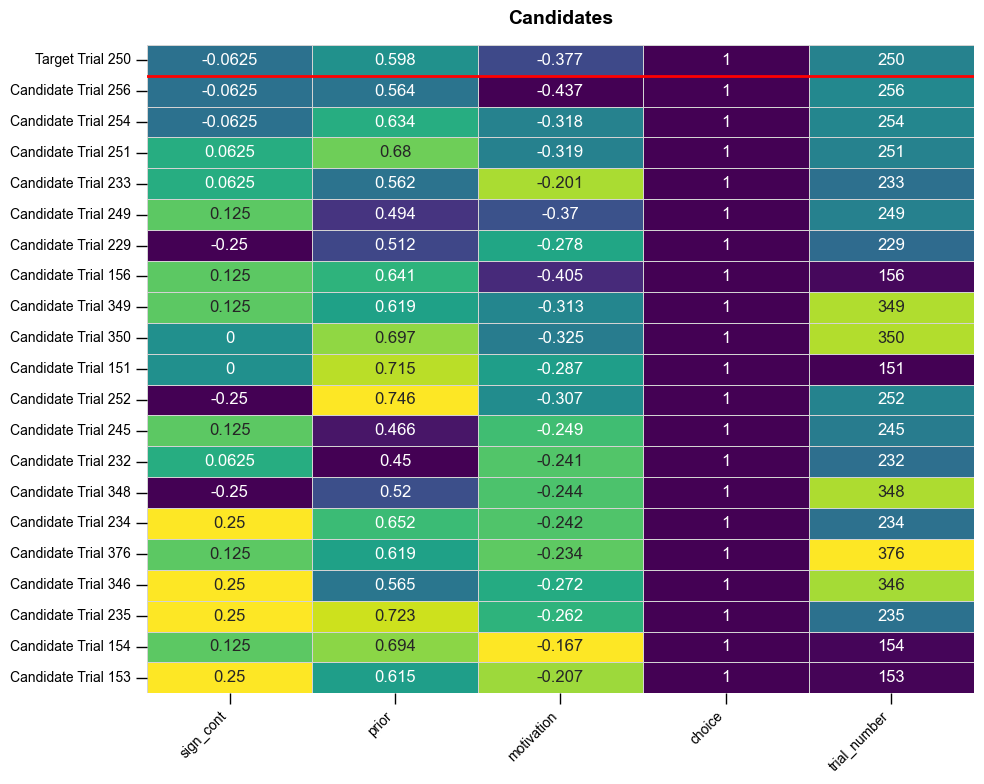

In [72]:
cols = ["sign_cont", "prior", "motivation", "choice", "trial_number"]

# Call the function for a specific target trial (e.g., row 250)
plot_candidate_heatmap(trials, candidate_trials_all, target_idx=250, cols_to_plot=cols)

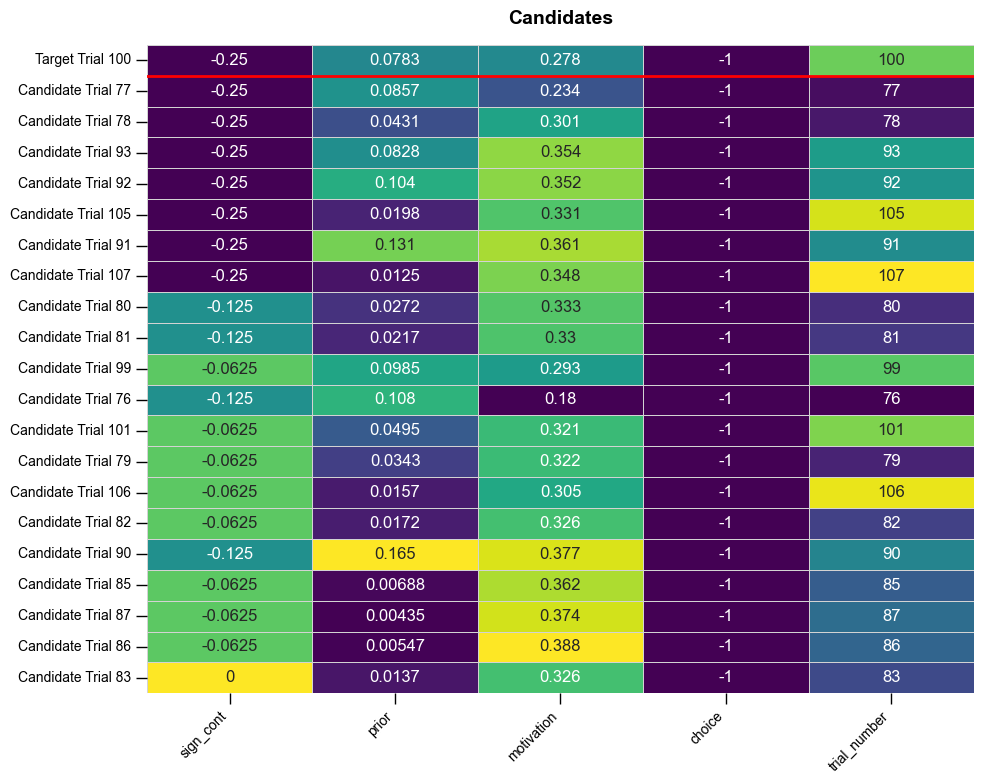

In [73]:
cols = ["sign_cont", "prior", "motivation", "choice", "trial_number"]

# Call the function for a specific target trial (e.g., row 250)
plot_candidate_heatmap(trials, candidate_trials_all, target_idx=100, cols_to_plot=cols)

In [42]:
rrr_data = pkl.load(
    open(
        "../data/generated/rrr_analysis/76448b54-0d56-469a-9c5b-6bdd3b7bce3d_rrr_results_all_trials.pkl",
        "rb",
    )
)

In [98]:
rrr_data_alt = pkl.load(
    open(
        "../data/generated/rrr_analysis/76448b54-0d56-469a-9c5b-6bdd3b7bce3d_rrr_results_all_trials_number.pkl",
        "rb",
    )
)

<Axes: >

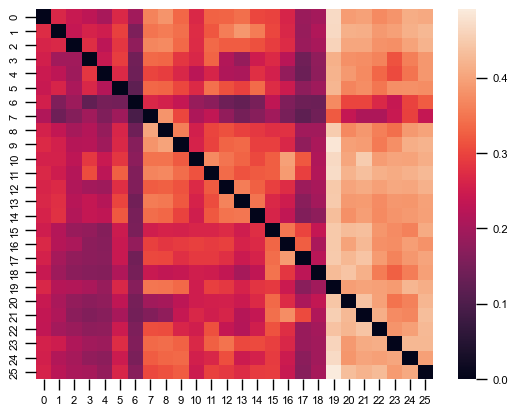

In [99]:
sns.heatmap(rrr_data["true_ridge_r2"])

<Axes: >

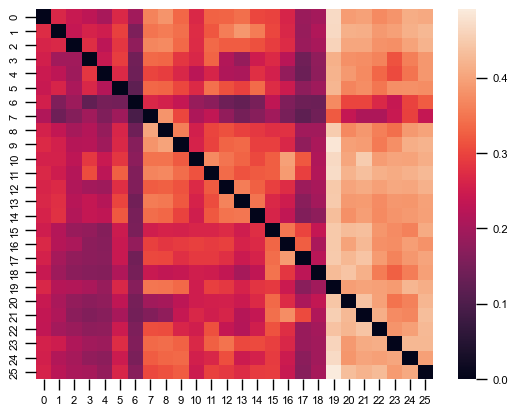

In [100]:
sns.heatmap(rrr_data_alt["true_ridge_r2"])

<Axes: >

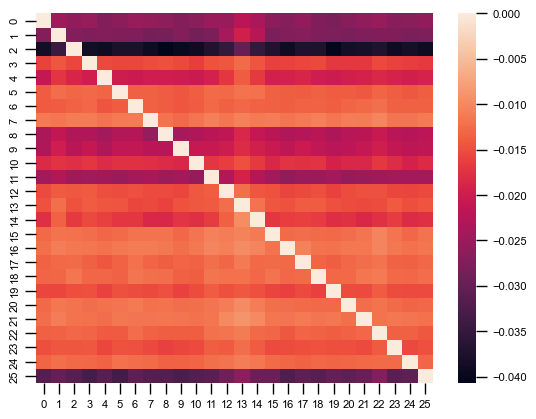

In [101]:
sns.heatmap(
    np.median(
        rrr_data["null_ridge_r2"][
            :,
            :,
        ],
        axis=2,
    )
)

In [76]:
true_r2 = rrr_data["true_ridge_r2"]
null_r2 = rrr_data["null_ridge_r2"]

In [ ]:
true_r2 = rrr_data["true_ridge_r2"]
null_r2 = rrr_data["null_ridge_r2"]
print("TRUE:", true_r2[0, 1])

null = null_r2[0, 1, :]

print("NULL mean:", np.mean(null))
print("NULL std:", np.std(null))
print("NULL max:", np.max(null))
print("NULL 95:", np.percentile(null, 95))

TRUE: 0.26606874322429014
NULL mean: -0.02469537507139928
NULL std: 0.011451898743978704
NULL max: 0.005614383476648404
NULL 95: -0.007885277551191384


In [78]:
true_r2 = rrr_data_alt["true_ridge_r2"]
null_r2 = rrr_data_alt["null_ridge_r2"]
print("TRUE:", true_r2[0, 1])

null = null_r2[0, 1, :]

print("NULL mean:", np.mean(null))
print("NULL std:", np.std(null))
print("NULL max:", np.max(null))
print("NULL 95:", np.percentile(null, 95))

TRUE: 0.26606874322429014
NULL mean: -0.022593808873030755
NULL std: 0.012097546657241599
NULL max: 0.021799785823382257
NULL 95: -0.00034189275054499556


In [93]:
rrr_data["regions"]

['MOB',
 'MOp',
 'MOs',
 'SSp-n',
 'SSp-m',
 'SSp-un',
 'PL',
 'RSPv',
 'RSPd',
 'RSPagl',
 'SSs',
 'SSp-bfd',
 'SSp-tr',
 'SSp-ll',
 'SSp-ul',
 'TEa',
 'AUDd',
 'AUDp',
 'VISpor',
 'VISpm',
 'VISl',
 'VISal',
 'VISrl',
 'VISa',
 'VISam',
 'VISp']

Text(0.5, 1.0, 'VISam -> MOp')

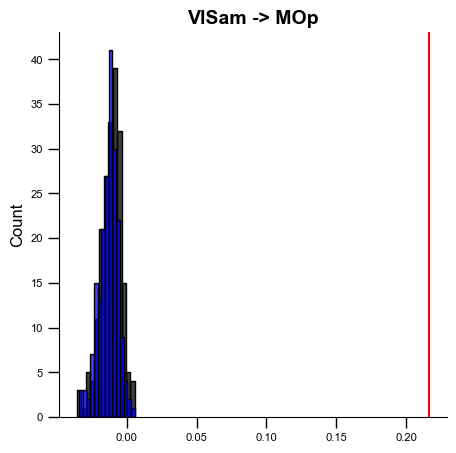

In [102]:
idx = 24
idy = 1
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(rrr_data_alt["null_ridge_r2"][idx, idy, :])
sns.histplot(rrr_data["null_ridge_r2"][idx, idy, :], color="blue")
ax.axvline(rrr_data["true_ridge_r2"][idx, idy], color="red")
ax.set_title(f"{rrr_data['regions'][idx]} -> {rrr_data['regions'][idy]}")
# ax.set_xlim(-0.5, 1)